# Ordinary Differential Equation

Differential equations describe the relationship between a function and its derivatives and are fundamental in computational physics. Two important classes are initial value problems (IVPs), where the solution is determined from conditions at a single point, and boundary value problems (BVPs), where conditions are specified at multiple points in the domain. This notebook demonstrates both types using a critically damped oscillator and the one-dimensional Laplace equation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Initial Value Problem

Consider the second-order ordinary differential equation

$$
m\ddot{x}+c\dot{x}+kx=0
$$

where $m$ is the mass, $c$ is the damping coefficient, and $k$ is the spring constant. For a critically damped system,

$$
c=2\sqrt{mk}.
$$

To solve the equation numerically, it is rewritten as a first-order system by introducing the velocity and acceleration,

$$
v=\dot{x},\qquad
a=\dot{v}=-\frac{c}{m}v-\frac{k}{m}x.
$$

The initial conditions are

$$
x(0)=1,\qquad
v(0)=0.
$$

In [3]:
m, k = 1, 1
c = 2*np.sqrt(m*k)

In [4]:
def rhs(t, y):
    x, v = y
    dxdt, dvdt = v, -(c/m)*v - (k/m)*x
    return [dxdt, dvdt]

In [5]:
y0 = [1, 0]
t_span = (0, 10)
t_eval = np.linspace(*t_span, 1000)

The IVP is solved using `scipy.integrate.solve_ivp` with several numerical methods, including explicit Runge-Kutta schemes (RK23, RK45, DOP853) and implicit or adaptive solvers (Radau, BDF, LSODA). The resulting displacement $x$ and velocity $v$ histories are compared over the simulation interval.

In [6]:
methods = ["RK23", "RK45", "DOP853", "Radau", "BDF", "LSODA"]
solutions = {}
for method in methods:
    sol = solve_ivp(rhs, t_span, y0, method=method, t_eval=t_eval)
    solutions[method] = sol.y

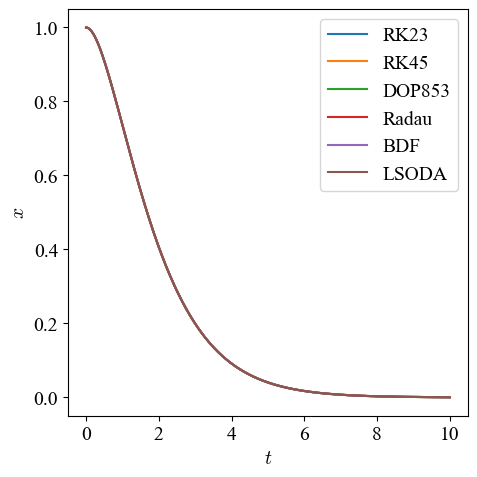

In [7]:
plt.figure(figsize=(5, 5))
for method in methods:
    x = solutions[method][0]
    plt.plot(t_eval, x, label=method)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

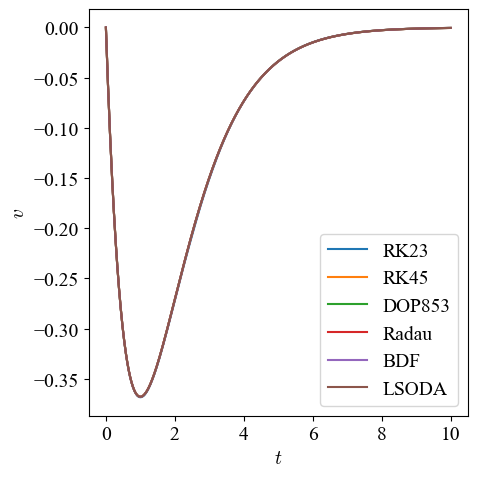

In [8]:
plt.figure(figsize=(5, 5))
for method in methods:
    v = solutions[method][1]
    plt.plot(t_eval, v, label=method)
plt.xlabel(r"$t$")
plt.ylabel(r"$v$")
plt.legend()
plt.tight_layout()
plt.show()

For a critically damped oscillator, the analytical displacement is

$$
x(t)=(A+Bt)e^{-\omega t},
$$

where

$$
\omega=\sqrt{\frac{k}{m}},\qquad
A=x(0),\qquad
B=v(0)+\omega x(0).
$$

This solution is used to evaluate the numerical error of each integration method.

In [9]:
omega = np.sqrt(k/m)
A, B = y0[0], y0[1] + omega * y0[0]
x_exact = (A + B*t_eval) * np.exp(-omega*t_eval)

The error for each solver is computed using the Euclidean norm $\lVert x_{num}-x_{exact}\rVert_2$, which measures the overall difference between the numerical and analytical displacement trajectories.

In [10]:
errors = {}
for method in methods:
    errors[method] = np.linalg.norm(solutions[method][0] - x_exact)

In [11]:
for method, error in errors.items():
    print(f"{method:<7}: {error:.3e}")

RK23   : 1.023e-02
RK45   : 6.492e-04
DOP853 : 2.921e-04
Radau  : 2.109e-04
BDF    : 2.163e-03
LSODA  : 7.980e-04


## Boundary Value Problem

Consider the one-dimensional Laplace equation

$$
\frac{d^2V}{dx^2}=0,
$$

subject to the boundary conditions

$$
V(0)=10,\qquad
V(1)=20.
$$

To solve the equation numerically, it is rewritten as a first-order system by introducing the electric field

$$
E=\frac{dV}{dx}.
$$

The resulting system becomes

$$
\frac{dV}{dx}=E,\qquad
\frac{dE}{dx}=0.
$$

In [12]:
def laplace(x, y):
    V, E = y
    return np.vstack((E, np.zeros_like(E)))

In [13]:
def bc(ya, yb):
    return np.array([ya[0] - 10, yb[0] - 20])

In [14]:
x_eval = np.linspace(0, 1, 1000)
y_guess = np.zeros((2, x_eval.size))
v_exact = 10 * x_eval + 10

The BVP is solved using `scipy.integrate.solve_bvp`, which iteratively adjusts the solution so that both boundary conditions are satisfied simultaneously.

In [15]:
sol = solve_bvp(laplace, bc, x_eval, y_guess)

Since the second derivative is zero, the exact solution is linear $V(x)=10x+10$. The numerical and analytical solutions are plotted together for comparison.

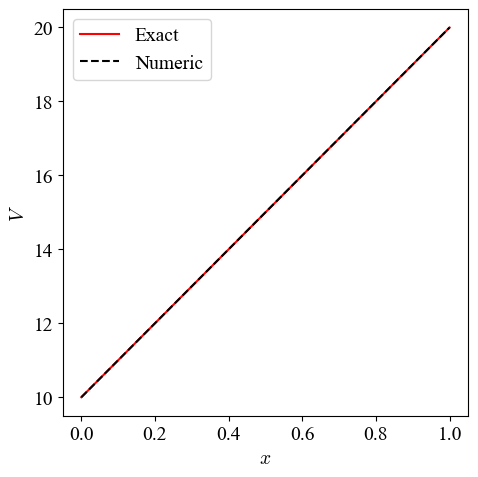

In [16]:
plt.figure(figsize=(5, 5))
plt.plot(x_eval, v_exact, color="r", label="Exact")
plt.plot(sol.x, sol.y[0], "--", color="k", label="Numeric")
plt.xlabel(r"$x$")
plt.ylabel(r"$V$")
plt.legend()
plt.tight_layout()
plt.show()

The BVP error is evaluated using the Euclidean norm $\lVert V_{num}-V_{exact}\rVert_2$, which quantifies the difference between the numerical and analytical potential distributions.

In [17]:
error = np.linalg.norm(sol.y[0] - v_exact)
print(f"L2 Error: {error:.3e}")

L2 Error: 3.499e-13


## Key Insights

* IVPs specify the solution at a single initial point, whereas BVPs impose conditions at multiple points in the domain.
* `solve_ivp` is designed for time-evolution problems such as damped oscillators.
* `solve_bvp` is designed for spatial boundary-value problems such as the Laplace equation.